<a href="https://colab.research.google.com/github/NayabShahbaz/SmolDoclingEval-F26-04/blob/main/F26_04_Phase4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 4 — Evaluation & Metric Computation for SmolDocling
**F26-04 | Track C | SmolDocling Implementation**

This phase computes paper Table 2 metrics (Edit Distance, F1, Precision, Recall, BLEU, METEOR) on Im2LaTeX and DocLayNet for **both SmolDocling and Nougat**, and TEDS on PubTables for **SmolDocling vs TATR**. Includes error analysis, length/numeric bias checks, and a final comparison table.

## Inputs (uploaded from Phase 3)
1. `smoldocling_latex_results.csv`
2. `smoldocling_doclaynet_results.jsonl`
3. `smoldocling_pubtables_results.csv`
4. `nougat_latex_results.csv`
5. `nougat_doclaynet_results.jsonl`
6. `tatr_pubtables_results.csv`
7. PubTables ground truth OTSL `.txt` files (from Phase 2)

## Section 1 — Install and import

In [3]:
!pip install -q python-Levenshtein nltk lxml apted pandas tqdm pytesseract
!apt-get install -qq tesseract-ocr 2>/dev/null

import pandas as pd
import json, re, os
from pathlib import Path
import Levenshtein
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from tqdm.auto import tqdm
from lxml import etree
from apted import APTED, Config

nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

smooth = SmoothingFunction().method1   # Avoid BLEU=0 on missing n-grams

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.1 MB/s eta 0:00:00


## Section 2 — Shared utilities

Output stripping: SmolDocling outputs DocTags, Nougat outputs Mathpix-Markdown. Both must be stripped to plain text before comparing against plain-text ground truth (from Im2LaTeX `.txt` files or DocLayNet OCR). Otherwise metrics get polluted by markup characters that have nothing to do with content correctness.

In [4]:
def strip_doctags(text):
    """Remove all <tag> wrappers from SmolDocling output, keep only inner content."""
    text = str(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def strip_mmd(text):
    """Remove Mathpix-Markdown formatting from Nougat output."""
    text = str(text)
    text = re.sub(r'\\\(|\\\)|\\\[|\\\]', '', text)   # math delimiters
    text = re.sub(r'^#{1,6}\s+', '', text, flags=re.MULTILINE)   # headers
    text = re.sub(r'\*{1,2}([^*]+)\*{1,2}', r'\1', text)         # bold/italic
    text = re.sub(r'\|', ' ', text)                              # table pipes
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def normalize_latex(text):
    """Normalize LaTeX for fair comparison: collapse whitespace, strip outer braces."""
    text = str(text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


# Metric functions — character-level Edit Distance + token-level BLEU/METEOR/F1
def compute_metrics(gts, preds, name=''):
    """
    Compute all 6 paper metrics (Table 2) on parallel lists of ground truth + predictions.
    Returns a dict with mean values.
    """
    edit_distances, bleus, meteors = [], [], []
    precisions, recalls, f1s = [], [], []

    for g, p in zip(gts, preds):
        g, p = str(g), str(p)

        # Normalized character-level Edit Distance (paper definition: divide by length of GT)
        ed = Levenshtein.distance(g, p) / max(1, len(g),len(p))
        edit_distances.append(ed)

        # Token-level BLEU (with smoothing to avoid 0 on short sequences)
        g_tokens = g.split()
        p_tokens = p.split()
        if g_tokens and p_tokens:
            bleus.append(sentence_bleu([g_tokens], p_tokens, smoothing_function=smooth))
            meteors.append(meteor_score([g_tokens], p_tokens))
        else:
            bleus.append(0.0)
            meteors.append(0.0)

        # Token-set Precision/Recall/F1 (paper definition)
        g_set, p_set = set(g_tokens), set(p_tokens)
        tp = len(g_set & p_set)
        fp = len(p_set - g_set)
        fn = len(g_set - p_set)
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
        precisions.append(prec)
        recalls.append(rec)
        f1s.append(f1)

    n = len(gts)
    results = {
        'Edit Distance': sum(edit_distances) / n,
        'F1': sum(f1s) / n,
        'Precision': sum(precisions) / n,
        'Recall': sum(recalls) / n,
        'BLEU': sum(bleus) / n,
        'METEOR': sum(meteors) / n,
    }

    print(f'\n=== {name} (n={n}) ===')
    for k, v in results.items():
        print(f'  {k}: {v:.4f}')
    return results

In [5]:


#downloading tables again for groundtruth matching as .csb just have file name
import os
URL = "https://huggingface.co/datasets/bsmock/pubtables-1m/resolve/main/PubTables-1M-Structure_Annotations_Test.tar.gz"
os.makedirs('/content/pubtables', exist_ok=True)
!wget -q -O /content/pubtables/structure_test.tar.gz "{URL}"
!tar -xzf /content/pubtables/structure_test.tar.gz -C /content/pubtables/

import glob
xml_files = glob.glob('/content/pubtables/**/*.xml', recursive=True)
ANNOTATIONS_DIR = os.path.dirname(xml_files[0])
print(f'Found {len(xml_files)} XML files in {ANNOTATIONS_DIR}')

Found 93834 XML files in /content/pubtables


## Section 3 — Upload all Phase 3 result files

In [6]:
from google.colab import files
print('Upload all 6 result files')
uploaded = files.upload()
print(f'\nUploaded: {list(uploaded.keys())}')

Upload all 6 result files (and PubTables ground truth zip if separate):


Saving nougat_latex_results.csv to nougat_latex_results.csv
Saving nougat_doclaynet_results.jsonl to nougat_doclaynet_results.jsonl
Saving smoldocling_doclaynet_results.jsonl to smoldocling_doclaynet_results.jsonl
Saving smoldocling_latex_results.csv to smoldocling_latex_results.csv
Saving smoldocling_pubtables_results.csv to smoldocling_pubtables_results.csv
Saving tatr_pubtables_results.csv to tatr_pubtables_results.csv

Uploaded: ['nougat_latex_results.csv', 'nougat_doclaynet_results.jsonl', 'smoldocling_doclaynet_results.jsonl', 'smoldocling_latex_results.csv', 'smoldocling_pubtables_results.csv', 'tatr_pubtables_results.csv']


##Get the tables that are ground truth

In [7]:
import xml.etree.ElementTree as ET
from pathlib import Path
from tqdm.auto import tqdm
import pandas as pd

# ---------- CONFIG ----------
ANNOTATIONS_PATH = Path(ANNOTATIONS_DIR)
OUTPUT_DIR = Path('/content/pubtables/ground_truth_otsl')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Get the image_names we actually need GT for
# Combine SmolDocling and TATR predictions to cover both subsets
needed_names = set()
for csv_file in ['/content/smoldocling_pubtables_results.csv',
                 '/content/tatr_pubtables_results.csv']:
    if Path(csv_file).exists():
        df = pd.read_csv(csv_file)
        needed_names.update(df['image_name'].astype(str).tolist())

print(f'Need ground truth for {len(needed_names)} unique tables')


# ---------- STEP 1: READ XML ----------
def read_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    size = root.find('size')
    img_w = int(size.find('width').text)
    img_h = int(size.find('height').text)
    objects = []
    for obj in root.findall('object'):
        label = obj.find('name').text
        bnd = obj.find('bndbox')
        x1, y1 = float(bnd.find('xmin').text), float(bnd.find('ymin').text)
        x2, y2 = float(bnd.find('xmax').text), float(bnd.find('ymax').text)
        row_span, col_span = 1, 1
        attrs = obj.find('attributes')
        if attrs is not None:
            for attr in attrs.findall('attribute'):
                name = attr.find('name').text
                value = attr.find('value').text
                if name == 'row_span': row_span = int(value)
                elif name == 'column_span': col_span = int(value)
        objects.append({
            'label': label, 'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
            'row_span': row_span, 'col_span': col_span
        })
    return (img_w, img_h), objects


# ---------- STEP 2: BUILD OTSL  ----------
def build_otsl(objects, img_w, img_h):
    rows = sorted([o for o in objects if o['label'] == 'table row'],
                  key=lambda o: (o['y1'] + o['y2']) / 2)
    cols = sorted([o for o in objects if o['label'] == 'table column'],
                  key=lambda o: (o['x1'] + o['x2']) / 2)
    headers = [o for o in objects if o['label'] == 'table column header']
    spans = [o for o in objects if o['label'] in (
        'table spanning cell', 'table projected row header')]
    n_rows, n_cols = len(rows), len(cols)
    if n_rows == 0 or n_cols == 0:
        return ''
    grid = {}
    for ri, row in enumerate(rows):
        for ci, col in enumerate(cols):
            grid[(ri, ci)] = (
                max(row['x1'], col['x1']), max(row['y1'], col['y1']),
                min(row['x2'], col['x2']), min(row['y2'], col['y2'])
            )
    header_rows = set()
    for hdr in headers:
        for ri, row in enumerate(rows):
            if min(hdr['y2'], row['y2']) - max(hdr['y1'], row['y1']) > 0:
                header_rows.add(ri)
    span_type = {}
    for span in spans:
        best_overlap, anchor = 0, (0, 0)
        for (ri, ci), (cx1, cy1, cx2, cy2) in grid.items():
            ov = (max(0, min(span['x2'], cx2) - max(span['x1'], cx1)) *
                  max(0, min(span['y2'], cy2) - max(span['y1'], cy1)))
            if ov > best_overlap:
                best_overlap, anchor = ov, (ri, ci)
        ar, ac = anchor
        for dr in range(span['row_span']):
            for dc in range(span['col_span']):
                r, c = ar + dr, ac + dc
                if r >= n_rows or c >= n_cols or (dr == 0 and dc == 0):
                    continue
                if dr > 0 and dc > 0: span_type[(r, c)] = 'X'
                elif dc > 0: span_type[(r, c)] = 'L'
                else: span_type[(r, c)] = 'U'
    tokens = []
    for ri in range(n_rows):
        for ci in range(n_cols):
            st = span_type.get((ri, ci))
            if st == 'L': tokens.append('<lcel>')
            elif st == 'U': tokens.append('<ucel>')
            elif st == 'X': tokens.append('<xcel>')
            elif ri in header_rows: tokens.append('<ched></ched>')
            else: tokens.append('<ecel>')
        tokens.append('<nl>')
    return '<otsl>' + ' '.join(tokens) + '</otsl>'


# ---------- MAIN LOOP — ONLY PROCESS NEEDED XMLs ----------
all_xml = sorted(ANNOTATIONS_PATH.glob('*.xml'))

# Filter to only the XMLs we have predictions for
needed_xml = [x for x in all_xml if x.stem in needed_names]
print(f'Filtered {len(all_xml)} XMLs down to {len(needed_xml)} needed ones')

success, skipped = 0, 0
for xml_path in tqdm(needed_xml, desc='Converting to OTSL'):
    sample_id = xml_path.stem
    output_path = OUTPUT_DIR / f'{sample_id}.txt'
    try:
        (img_w, img_h), objects = read_xml(xml_path)
        otsl = build_otsl(objects, img_w, img_h)
        if not otsl:
            skipped += 1
            continue
        with open(output_path, 'w', encoding='utf-8') as f:
            f.write(otsl)
        success += 1
    except Exception as e:
        skipped += 1

print(f'\nSuccessfully converted: {success}')
print(f'Skipped: {skipped}')
print(f'Output: {OUTPUT_DIR}')

# ---------- ZIP IT ----------
!zip -qr /content/pubtables_gt_otsl.zip /content/pubtables/ground_truth_otsl/
print(f'\nZipped to /content/pubtables_gt_otsl.zip')
!ls -lh /content/pubtables_gt_otsl.zip

Need ground truth for 187 unique tables
Filtered 93834 XMLs down to 187 needed ones


Converting to OTSL:   0%|          | 0/187 [00:00<?, ?it/s]


Successfully converted: 187
Skipped: 0
Output: /content/pubtables/ground_truth_otsl

Zipped to /content/pubtables_gt_otsl.zip
-rw-r--r-- 1 root root 53K Apr 26 10:55 /content/pubtables_gt_otsl.zip


## Section 4 — Im2LaTeX evaluation: SmolDocling vs Nougat

Targets from paper Table 2:
- SmolDocling: ED 0.11, F1 0.95, BLEU 0.83, Precision:0.96 , Recall: 0.95, METEOR: 0.89
- Nougat: ED 0.62, F1 0.60, BLEU 0.33, Precision: 0.6, Recall: 0.53, METEOR: 0.41

In [8]:
df_smol_latex = pd.read_csv('smoldocling_latex_results.csv')
smol_gt = [normalize_latex(x) for x in df_smol_latex['ground_truth_latex']]
smol_pred = [normalize_latex(strip_doctags(x)) for x in df_smol_latex['prediction_raw']]
smol_latex_metrics = compute_metrics(smol_gt, smol_pred, 'SmolDocling — Im2LaTeX')

df_nougat_latex = pd.read_csv('nougat_latex_results.csv')
nou_gt = [normalize_latex(x) for x in df_nougat_latex['ground_truth_latex']]
nou_pred = [normalize_latex(strip_mmd(x)) for x in df_nougat_latex['prediction_raw']]
nougat_latex_metrics = compute_metrics(nou_gt, nou_pred, 'Nougat — Im2LaTeX')


=== SmolDocling — Im2LaTeX (n=50) ===
  Edit Distance: 0.1273
  F1: 0.9089
  Precision: 0.9208
  Recall: 0.8995
  BLEU: 0.8054
  METEOR: 0.8497

=== Nougat — Im2LaTeX (n=50) ===
  Edit Distance: 0.8262
  F1: 0.0217
  Precision: 0.0423
  Recall: 0.0171
  BLEU: 0.0003
  METEOR: 0.0040


## Section 5 — DocLayNet evaluation: SmolDocling vs Nougat

Targets from paper Table 2:
- SmolDocling: ED 0.48, F1 0.80, BLEU 0.58,Precision: 0.89, Recall: 0.79, METEOR: 0.67
- Nougat: ED 0.62, F1 0.66, BLEU 0.44, Precision: 0.72, Recall: 0.67, METEOR: 0.67

**Caveat:** DocLayNet pages have no full-text ground truth. We use Tesseract OCR as a proxy ground truth. This means we're really measuring "how close are the model outputs to Tesseract's OCR", not absolute accuracy. Both SmolDocling and Nougat are evaluated against the same Tesseract output, so the relative comparison is still valid — only the absolute scores are compromised.

In [9]:
!apt-get install -y tesseract-ocr -qq
!pip install -q pytesseract pillow datasets

In [10]:
import re
import json
import os
import pytesseract
from tqdm.auto import tqdm
from datasets import load_dataset

CACHE_FILE = '/content/tesseract_gts.jsonl'

# Skip Tesseract if we already have the cached ground truth
if os.path.exists(CACHE_FILE):
    tesseract_gts = []
    with open(CACHE_FILE) as f:
        for line in f:
            tesseract_gts.append(json.loads(line)['ground_truth'])
    print(f'✓ Loaded {len(tesseract_gts)} Tesseract ground truth pages from cache')
else:
    # First run — generate from scratch
    print('Loading DocLayNet test split + running Tesseract OCR on first 50 pages...')
    ds = load_dataset('docling-project/DocLayNet-v1.2', split='test', streaming=True)

    tesseract_gts = []
    with open(CACHE_FILE, 'w') as f:
        for i, example in enumerate(tqdm(ds, total=50, desc='Tesseract')):
            if i >= 50:
                break
            text = pytesseract.image_to_string(example['image'])
            text = re.sub(r'\s+', ' ', text).strip()
            tesseract_gts.append(text)

            # Write each entry as one JSONL line (with index, like the other files)
            f.write(json.dumps({'index': i, 'ground_truth': text}) + '\n')

    print(f'Generated and saved {len(tesseract_gts)} Tesseract ground truth pages')

Loading DocLayNet test split + running Tesseract OCR on first 50 pages...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Tesseract:   0%|          | 0/50 [00:00<?, ?it/s]

Generated and saved 50 Tesseract ground truth pages


In [12]:
import json, Levenshtein

# Load GTs and predictions
if 'tesseract_gts' not in globals() or not tesseract_gts:
    tesseract_gts = []
    with open('/content/tesseract_gts.jsonl') as f:
        for line in f:
            tesseract_gts.append(json.loads(line)['ground_truth'])

smol_doc = [json.loads(l) for l in open('smoldocling_doclaynet_results.jsonl')]
nou_doc  = [json.loads(l) for l in open('nougat_doclaynet_results.jsonl')]
smol_doc_pred = [d['prediction_stripped'] for d in smol_doc[:50]]
nou_doc_pred  = [d['prediction_stripped'] for d in nou_doc[:50]]

# Drop pages with empty/near-empty GT (Tesseract failures)
MIN_GT_LEN = 50
valid_idx = [i for i, g in enumerate(tesseract_gts) if len(g) >= MIN_GT_LEN]
print(f'Keeping {len(valid_idx)}/{len(tesseract_gts)} pages (dropped {len(tesseract_gts)-len(valid_idx)} with GT < {MIN_GT_LEN} chars)')

gts_v       = [tesseract_gts[i]  for i in valid_idx]
smol_pred_v = [smol_doc_pred[i]  for i in valid_idx]
nou_pred_v  = [nou_doc_pred[i]   for i in valid_idx]

smol_doclaynet_metrics = compute_metrics(gts_v, smol_pred_v, 'SmolDocling — DocLayNet')
nougat_doclaynet_metrics = compute_metrics(gts_v, nou_pred_v, 'Nougat — DocLayNet')

Keeping 47/50 pages (dropped 3 with GT < 50 chars)

=== SmolDocling — DocLayNet (n=47) ===
  Edit Distance: 0.3498
  F1: 0.6614
  Precision: 0.7178
  Recall: 0.6393
  BLEU: 0.5113
  METEOR: 0.6300

=== Nougat — DocLayNet (n=47) ===
  Edit Distance: 0.6578
  F1: 0.3691
  Precision: 0.5834
  Recall: 0.3255
  BLEU: 0.1827
  METEOR: 0.2740


Dropped pages: [11, 12, 28]


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]


=== Page 11 ===
Tesseract GT (len 0): ''
SmolDocling pred (first 300): ''
Doc category: ?


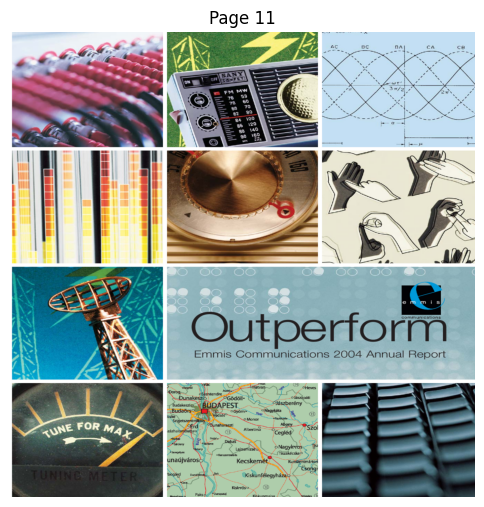


=== Page 12 ===
Tesseract GT (len 0): ''
SmolDocling pred (first 300): 'Text Drei D Eman Text Drei D Eman Text Drei D Eman Text Drei D Eman Text Drei D Eman Text Drei D Eman Text Drei D Eman Text Drei D Eman Text Drei D Eman Text Drei D Eman Text Drei D Eman Text Drei D Eman Text Drei D Eman Text Drei D Eman Text Drei D Eman Text Drei D Eman Text Drei D Eman Text Drei D'
Doc category: ?


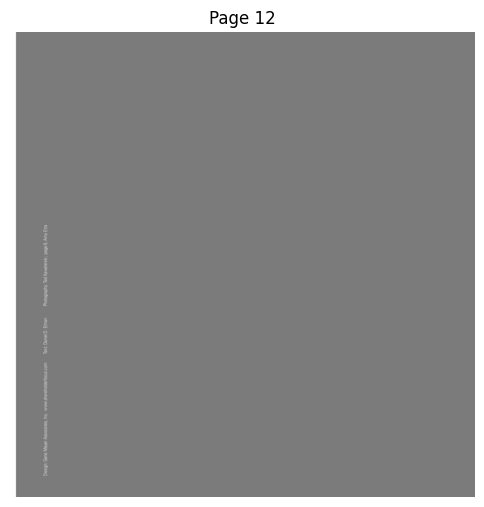


=== Page 28 ===
Tesseract GT (len 0): ''
SmolDocling pred (first 300): "SEEKING INVESTORS FOR A PERFECT MATCH Join us in the dynamic, aggressive, profitable growth of HON INDUSTRIES. THE BEST IS YET TO COME! Management's Discussion and Analysis ... 32 Consolidated Financial Statements and Notes ... 39 Eleven-Year Summary ... 56 Reports of Independent Auditors ... 58 A M"
Doc category: ?


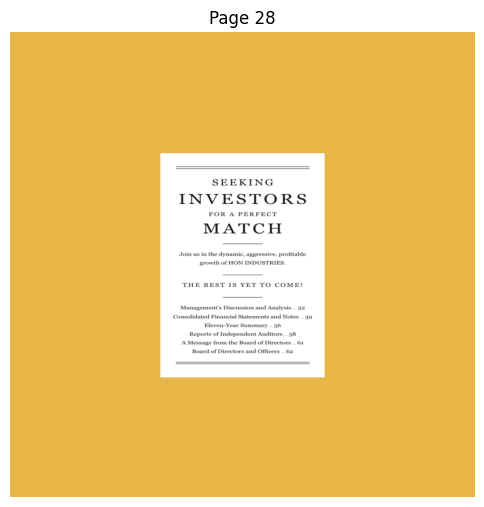

In [13]:
# Inspect the 3 dropped pages — are they Tesseract failures or genuinely empty?
from datasets import load_dataset
import matplotlib.pyplot as plt

dropped_idx = [i for i, g in enumerate(tesseract_gts) if len(g) < 50]
print(f'Dropped pages: {dropped_idx}')

ds = load_dataset('docling-project/DocLayNet-v1.2', split='test', streaming=True)
for idx, example in enumerate(ds):
    if idx in dropped_idx:
        gt = tesseract_gts[idx]
        pred = smol_doc_pred[idx]
        print(f'\n=== Page {idx} ===')
        print(f'Tesseract GT (len {len(gt)}): {gt!r}')
        print(f'SmolDocling pred (first 300): {pred[:300]!r}')
        print(f'Doc category: {example.get("doc_category", "?")}')
        # Show the image so you can eyeball it
        plt.figure(figsize=(6, 8))
        plt.imshow(example['image'])
        plt.title(f'Page {idx}')
        plt.axis('off')
        plt.show()
    if idx >= max(dropped_idx):
        break

## Section 6 — PubTables evaluation: TEDS for SmolDocling vs TATR

Target from paper Table 4: SmolDocling structure-only TEDS = 0.88 (TableFormer 0.84).



In [14]:
OTSL_TAG_RE = re.compile(r'<(fcel|ecel|lcel|ucel|xcel|nl|ched|rhed|srow)>')

class Node:
    """APTED-compatible tree node."""
    def __init__(self, name, children=None):
        self.name = name
        self.children = children if children is not None else []

def parse_otsl_to_tree(otsl_string):
    """Convert OTSL string to an APTED tree of rows and cells."""
    s = str(otsl_string)
    s = re.sub(r'<otsl>|</otsl>', '', s)
    s = re.sub(r'<loc_\d+>', '', s)
    s = re.sub(r'<caption>.*?</caption>', '', s, flags=re.DOTALL)

    tokens = OTSL_TAG_RE.findall(s)
    if not tokens:
        return None

    rows = [[]]
    for tok in tokens:
        if tok == 'nl':
            rows.append([])
        else:
            rows[-1].append(Node(f'td:{tok}'))

    # Drop trailing empty row
    if rows and not rows[-1]:
        rows.pop()
    if not rows:
        return None

    return Node('table', [Node('tr', cells) for cells in rows])


class TEDSConfig(Config):
    """APTED config: nodes match by their name string."""
    def rename(self, n1, n2):
        return 0 if n1.name == n2.name else 1

    def children(self, node):
        return node.children


def tree_size(node):
    if node is None:
        return 0
    return 1 + sum(tree_size(c) for c in node.children)


def compute_teds(gt_otsl, pred_otsl):
    """Tree Edit Distance Similarity, structure-only."""
    t1 = parse_otsl_to_tree(gt_otsl)
    t2 = parse_otsl_to_tree(pred_otsl)
    if t1 is None or t2 is None:
        return 0.0
    apted = APTED(t1, t2, TEDSConfig())
    dist = apted.compute_edit_distance()
    max_size = max(tree_size(t1), tree_size(t2))
    return 1.0 - (dist / max_size) if max_size > 0 else 0.0


# Sanity check: TEDS of a tree against itself = 1.0; against an empty table = small
_ex = '<otsl><ched><ched><nl><fcel><fcel><nl></otsl>'
_diff = '<otsl><ched><nl><fcel><nl></otsl>'
print(f'TEDS(same, same) = {compute_teds(_ex, _ex):.3f}  (should be 1.0)')
print(f'TEDS(2x2, 1x1)   = {compute_teds(_ex, _diff):.3f}  (should be < 1.0)')

TEDS(same, same) = 1.000  (should be 1.0)
TEDS(2x2, 1x1)   = 0.714  (should be < 1.0)


In [15]:
import os, zipfile
from pathlib import Path

ZIP_PATH = '/content/pubtables_gt_otsl.zip'
GT_DIR = Path('/content/pubtables/ground_truth_otsl')  # matches Phase 2 output path

# Unzip
if not GT_DIR.exists() or not any(GT_DIR.glob('*.txt')):
    if os.path.exists(ZIP_PATH):
        with zipfile.ZipFile(ZIP_PATH) as z:
            z.extractall('/')
        print(f'Unzipped {ZIP_PATH}')
    else:
        print(f'WARNING: {ZIP_PATH} not found. Upload the Phase 2 ground truth zip.')

# Load
gt_dict = {}
if GT_DIR.exists():
    for f in GT_DIR.glob('*.txt'):
        gt_dict[f.stem] = f.read_text()
    print(f'Loaded {len(gt_dict)} ground truth OTSL files from {GT_DIR}')
else:
    print(f'WARNING: {GT_DIR} not found after unzip — check the zip structure.')

Loaded 187 ground truth OTSL files from /content/pubtables/ground_truth_otsl


In [16]:
import re
from tqdm.auto import tqdm

def normalize_structure(otsl_string):
    if not isinstance(otsl_string, str) or not otsl_string.strip():
        return ""

    # 1. Remove location tokens
    otsl = re.sub(r'<loc_\d+>', '', otsl_string)
    # 2. Map tags
    otsl = otsl.replace('<fcel>', '<ecel>')
    # 3. Remove all content between tags, including leading/trailing
    otsl = re.sub(r'>[^<]+<', '><', otsl)
    otsl = re.sub(r'^[^<]+|[^>]+$', '', otsl)
    # 4. Standardize spacing
    otsl = otsl.replace('><', '> <')
    return re.sub(r'\s+', ' ', otsl).strip()

# ---------- SmolDocling Matching & TEDS ----------
df_smol_pub = pd.read_csv('smoldocling_pubtables_results.csv')
df_smol_pub['image_name'] = df_smol_pub['image_name'].astype(str).str.replace('.jpg', '').str.replace('.png', '')
df_smol_pub['ground_truth'] = df_smol_pub['image_name'].map(gt_dict)
df_smol_pub_matched = df_smol_pub.dropna(subset=['ground_truth']).copy()

print(f'SmolDocling: matched {len(df_smol_pub_matched)} / {len(df_smol_pub)} samples')

smol_teds = []
for _, row in tqdm(df_smol_pub_matched.iterrows(), total=len(df_smol_pub_matched), desc='SmolDocling Structure TEDS'):
    # Normalize both GT and Pred to structure-only before computing
    gt_struct = normalize_structure(row['ground_truth'])
    pred_struct = normalize_structure(row['prediction_raw'])
    smol_teds.append(compute_teds(gt_struct, pred_struct))

df_smol_pub_matched['TEDS'] = smol_teds
print(f'SmolDocling mean Structure TEDS: {df_smol_pub_matched["TEDS"].mean():.4f}')


# ---------- TATR Matching & TEDS ----------
df_tatr = pd.read_csv('tatr_pubtables_results.csv')
df_tatr['image_name'] = df_tatr['image_name'].astype(str).str.replace('.jpg', '').str.replace('.png', '')
df_tatr['ground_truth'] = df_tatr['image_name'].map(gt_dict)
df_tatr_matched = df_tatr.dropna(subset=['ground_truth']).copy()

print(f'TATR: matched {len(df_tatr_matched)} / {len(df_tatr)} samples')

tatr_teds = []
for _, row in tqdm(df_tatr_matched.iterrows(), total=len(df_tatr_matched), desc='TATR Structure TEDS'):
    # Apply the same normalization to TATR
    gt_struct = normalize_structure(row['ground_truth'])
    pred_struct = normalize_structure(row['prediction_raw'])
    tatr_teds.append(compute_teds(gt_struct, pred_struct))

df_tatr_matched['TEDS'] = tatr_teds
print(f'TATR mean Structure TEDS:        {df_tatr_matched["TEDS"].mean():.4f}')

SmolDocling: matched 100 / 100 samples


SmolDocling Structure TEDS:   0%|          | 0/100 [00:00<?, ?it/s]

SmolDocling mean Structure TEDS: 0.8659
TATR: matched 100 / 100 samples


TATR Structure TEDS:   0%|          | 0/100 [00:00<?, ?it/s]

TATR mean Structure TEDS:        0.9419


## Section 7 — Error analysis & bias check

Identify cases where each model fails badly, and check for systematic biases (page length, numeric content), done for Full page OCR DoclayNet Dataset

In [22]:
# Section 7 — Error analysis & bias check on DocLayNet (n=47, post-filter)

# Used the FILTERED lists (smol_pred_v, nou_pred_v) so rows align with gts_v.
# valid_idx is the list of original page numbers that survived the GT-length filter
# (defined back in Section 5 when we computed smol_doclaynet_metrics).

assert len(gts_v) == len(smol_pred_v) == len(nou_pred_v), "filtered lists must align"
print(f"Analyzing n={len(gts_v)} pages (after dropping pages with GT < 50 chars)")

doc_errors = pd.DataFrame({
    'orig_page': valid_idx,                    # original DocLayNet page number, for traceability
    'gt_text': gts_v,
    'smol_pred': smol_pred_v,
    'nou_pred': nou_pred_v,
})

# Same max-length normalization used for the headline metric
doc_errors['smol_ed'] = [Levenshtein.distance(g, p) / max(1, len(g), len(p))
                        for g, p in zip(gts_v, smol_pred_v)]
doc_errors['nou_ed']  = [Levenshtein.distance(g, p) / max(1, len(g), len(p))
                        for g, p in zip(gts_v, nou_pred_v)]
doc_errors['gt_length']    = doc_errors['gt_text'].str.split().str.len()
doc_errors['has_numeric']  = doc_errors['gt_text'].str.contains(r'\d')
doc_errors['pred_len_smol'] = doc_errors['smol_pred'].str.len()
doc_errors['pred_len_nou']  = doc_errors['nou_pred'].str.len()

# Flag likely repetition loops: prediction much longer than GT
doc_errors['smol_repetition_loop'] = doc_errors['pred_len_smol'] > 3 * doc_errors['gt_text'].str.len()
doc_errors['nou_repetition_loop']  = doc_errors['pred_len_nou']  > 3 * doc_errors['gt_text'].str.len()

print('\n=== Worst 5 SmolDocling DocLayNet cases (by edit distance) ===')
print(doc_errors.nlargest(5, 'smol_ed')[
    ['orig_page', 'gt_length', 'smol_ed', 'nou_ed', 'smol_repetition_loop']
])

print('\n=== Worst 5 Nougat DocLayNet cases (by edit distance) ===')
print(doc_errors.nlargest(5, 'nou_ed')[
    ['orig_page', 'gt_length', 'smol_ed', 'nou_ed', 'nou_repetition_loop']
])

print('\n=== Length bias (mean edit distance by GT word count) ===')
doc_errors['length_bucket'] = pd.cut(doc_errors['gt_length'],
                                      bins=[0, 50, 200, 10000],
                                      labels=['short (<50w)', 'medium (50-200w)', 'long (>200w)'])
print(doc_errors.groupby('length_bucket', observed=False)[['smol_ed', 'nou_ed']].mean().round(3))

print('\n=== Numeric content bias ===')
print(doc_errors.groupby('has_numeric')[['smol_ed', 'nou_ed']].mean().round(3))

print(f'\n=== Repetition-loop incidence ===')
print(f'  SmolDocling: {doc_errors["smol_repetition_loop"].sum()}/{len(doc_errors)} pages')
print(f'  Nougat:      {doc_errors["nou_repetition_loop"].sum()}/{len(doc_errors)} pages')


Analyzing n=47 pages (after dropping pages with GT < 50 chars)

=== Worst 5 SmolDocling DocLayNet cases (by edit distance) ===
    orig_page  gt_length   smol_ed    nou_ed  smol_repetition_loop
27         30        306  0.998532  0.700675                  True
44         47        225  0.997393  0.998092                  True
33         36         42  0.967597  0.983240                  True
14         16        146  0.873938  0.915014                 False
40         43        106  0.784369  0.762027                 False

=== Worst 5 Nougat DocLayNet cases (by edit distance) ===
    orig_page  gt_length   smol_ed    nou_ed  nou_repetition_loop
39         42        220  0.653309  1.000000                False
18         20        187  0.707941  0.998195                False
44         47        225  0.997393  0.998092                False
33         36         42  0.967597  0.983240                False
29         32        324  0.193612  0.948403                False

=== Length bias

In [19]:
# Per-category breakdown — all 47 are financial docs so sampling bias
from datasets import load_dataset

ds = load_dataset('docling-project/DocLayNet-v1.2', split='test', streaming=True)
categories_all = []
for i, ex in enumerate(ds):
    if i >= 50:
        break
    # The category lives at metadata.doc_category in v1.2
    meta = ex.get('metadata', {}) or {}
    categories_all.append(meta.get('doc_category', 'unknown'))

# Restrict to the n=47 filtered subset
doc_errors['doc_category'] = [categories_all[i] for i in valid_idx]

print('=== Sample distribution by category ===')
print(doc_errors['doc_category'].value_counts())

print('\n=== Mean ED per category (lower = better) ===')
print(doc_errors.groupby('doc_category')[['smol_ed', 'nou_ed']].agg(['mean', 'count']).round(3))

print('\n=== Nougat-minus-SmolDocling ED gap per category ===')
gap_by_cat = (
    doc_errors.groupby('doc_category')[['smol_ed', 'nou_ed']]
    .mean()
    .assign(gap=lambda d: (d['nou_ed'] - d['smol_ed']).round(3))
    .sort_values('gap', ascending=False)
    .round(3)
)
print(gap_by_cat)

# F1 breakdown
def row_f1(g, p):
    g_set, p_set = set(g.split()), set(p.split())
    tp = len(g_set & p_set); fp = len(p_set - g_set); fn = len(g_set - p_set)
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    return 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0

doc_errors['smol_f1'] = [row_f1(g, p) for g, p in zip(gts_v, smol_pred_v)]
doc_errors['nou_f1']  = [row_f1(g, p) for g, p in zip(gts_v, nou_pred_v)]

print('\n=== F1 per category (higher = better) ===')
f1_by_cat = (
    doc_errors.groupby('doc_category')[['smol_f1', 'nou_f1']]
    .mean()
    .assign(gap=lambda d: (d['smol_f1'] - d['nou_f1']).round(3))
    .sort_values('gap', ascending=False)
    .round(3)
)
print(f1_by_cat)

doc_errors.to_csv('/content/phase4_per_category_breakdown.csv', index=False)

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

=== Sample distribution by category ===
doc_category
financial_reports    47
Name: count, dtype: int64

=== Mean ED per category (lower = better) ===
                  smol_ed       nou_ed      
                     mean count   mean count
doc_category                                
financial_reports    0.35    47  0.658    47

=== Nougat-minus-SmolDocling ED gap per category ===
                   smol_ed  nou_ed    gap
doc_category                             
financial_reports     0.35   0.658  0.308

=== F1 per category (higher = better) ===
                   smol_f1  nou_f1    gap
doc_category                             
financial_reports    0.661   0.369  0.292
